In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

from adapt.instance_based import TrAdaBoostR2, TwoStageTrAdaBoostR2
from sklearn.metrics import mean_squared_error, mean_absolute_error

import itertools
from sklearn.preprocessing import StandardScaler

In [16]:
test_size = 1000
val_size = 1000

target_instances_list = [100,200,300]
source_instances = 1000 #we use a fixed number of source instances

d_list = [1,2,3,4,5]
seed_list = [1,2,3,4,5]

In [17]:
def gaussian_noise(n_samples, signal_y, snr=3.0, random_seed = None):
    """
    Generate Gaussian noise with variance scaled to achieve the desired SNR
    relative to the variance of signal_y.
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    signal_var = np.var(signal_y)
    target_noise_var = signal_var / snr
    noise = np.random.normal(0, 1, size=n_samples)
    noise_std = np.std(noise)
    noise *= np.sqrt(target_noise_var) / noise_std
    return noise


def slash_noise(n_samples, signal_y, snr=3.0, random_seed = None):
    """
    Generate Slash-distributed noise (Z/U) scaled to achieve desired SNR.
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    signal_var = np.var(signal_y)
    target_noise_var = signal_var / snr

    u = np.random.normal(0, 1, size=n_samples)
    v = np.random.uniform(0.001, 1, size=n_samples)
    raw_noise = u / v

    # Scale to achieve target variance
    noise_std = np.std(raw_noise)
    scaled_noise = raw_noise * np.sqrt(target_noise_var) / noise_std
    return scaled_noise

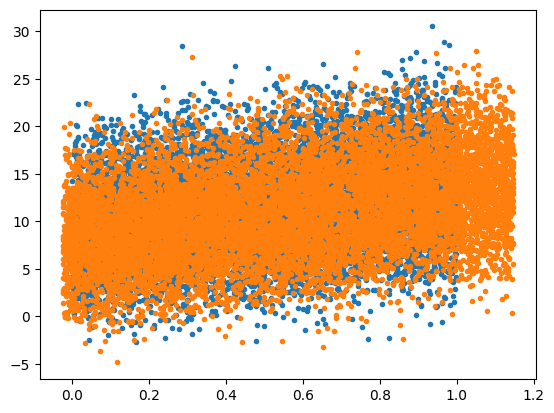

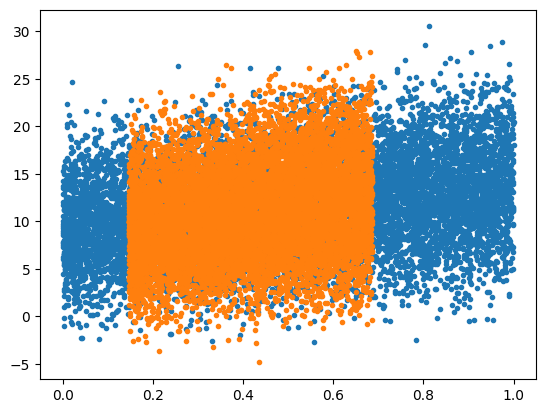

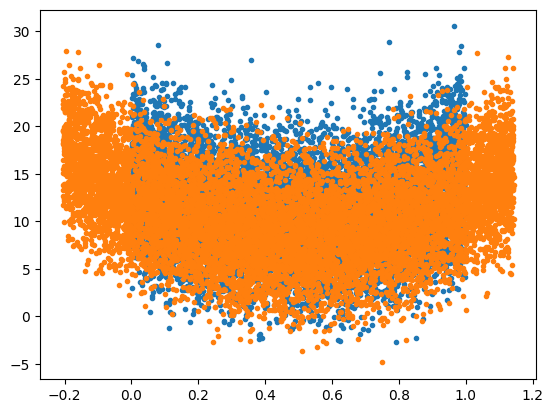

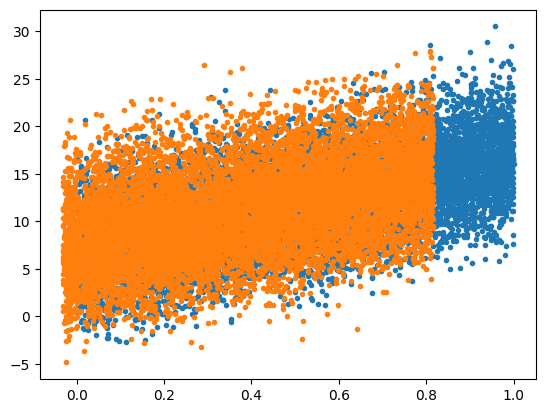

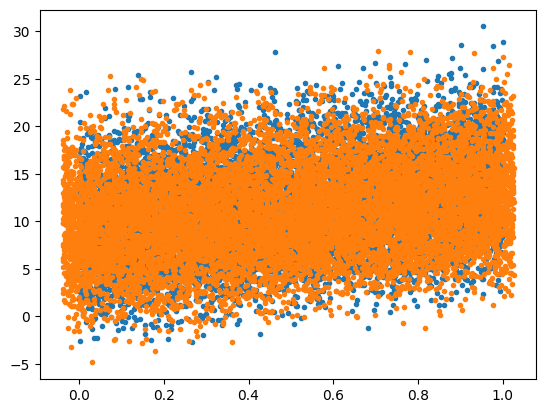

In [18]:
def friedman1(n_samples, add_noise=False, noise_distribution='gaussian', n_features=5, random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)

    x0 = np.random.uniform(0,1,size=n_samples)
    x1 = np.random.uniform(0,1,size=n_samples)
    x2 = np.random.uniform(0,1,size=n_samples)
    x3 = np.random.uniform(0,1,size=n_samples)
    x4 = np.random.uniform(0,1,size=n_samples)
    X = np.column_stack((x0, x1, x2, x3, x4)) 
    y = 10*np.sin(x0*x1) + 20*(x2 - 0.5)**2 + 10*x3 + 5*x4

    if add_noise:
        if noise_distribution == 'gaussian':
            if random_seed is not None:
                eps = gaussian_noise(n_samples, y, random_seed = random_seed)
            else:
                eps = gaussian_noise(n_samples, y)
            y += eps
        elif noise_distribution == 'slash':
            if random_seed is not None:
                eps = slash_noise(n_samples, y, random_seed = random_seed)
            else:
                eps = slash_noise(n_samples, y)
            
            y += eps
        else:
            raise Exception("No valid distribution, only gaussian or slash are accepted")

    if n_features > 5:
        noise_features = np.random.uniform(0, 1, size=(n_samples, n_features - 5))
        X = np.hstack((X, noise_features))

    return X, y


def friedman1_altered(n_samples, add_noise=False, noise_distribution='gaussian', n_features=5,
                      d = 1.0,
                      shift_seed=None, random_seed=None):

    if random_seed is not None:
        np.random.seed(random_seed)
    
    #generate distrubance factors
    a = np.random.normal(1, 0.2*d, size = 4)
    a0, a1, a2, a3 = a
    b = np.random.normal(1, 0.2*d, size = 5)
    b0, b1, b2, b3, b4 = b
    c = np.random.normal(0, 0.1*d, size = 5)
    c0, c1, c2, c3, c4 = c
    #

    #feature scaling
    x0 = np.random.uniform(0,1,size=n_samples) * b0 + c0
    x1 = np.random.uniform(0,1,size=n_samples) * b1 + c1
    x2 = np.random.uniform(0,1,size=n_samples) * b2 + c2
    x3 = np.random.uniform(0,1,size=n_samples) * b3 + c3
    x4 = np.random.uniform(0,1,size=n_samples) * b4 + c4
    

    X = np.column_stack((x0, x1, x2, x3, x4))
    #label scaling
    y = a0*10*np.sin(x0*x1) + a1*20*(x2 - 0.5)**2 + a2*10*x3 + a3*5*x4

    if add_noise:
        if noise_distribution == 'gaussian':
            eps = gaussian_noise(n_samples, y)
            y += eps
        elif noise_distribution == 'slash':
            eps = slash_noise(n_samples, y)
            y += eps
        else:
            raise Exception("No valid distribution, only gaussian or slash are accepted")

    if n_features > 5:
        noise_features = np.random.uniform(0, 1, size=(n_samples, n_features - 5))
        X = np.hstack((X, noise_features))

    return X, y



#Check that random seed works!
X, y = friedman1(10000, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed = 1)
X_altered, y_altered= friedman1_altered(n_samples=10000, add_noise = True, noise_distribution = 'gaussian',
                                                   n_features=10, d = 1, shift_seed=1, random_seed = 1) 

plt.plot(X[:,0], y, '.')
plt.plot(X_altered[:,0], y_altered, '.')
plt.show()

plt.plot(X[:,1], y, '.')
plt.plot(X_altered[:,1], y_altered, '.')
plt.show()

plt.plot(X[:,2], y, '.')
plt.plot(X_altered[:,2], y_altered, '.')
plt.show()

plt.plot(X[:,3], y, '.')
plt.plot(X_altered[:,3], y_altered, '.')
plt.show()

plt.plot(X[:,4], y, '.')
plt.plot(X_altered[:,4], y_altered, '.')
plt.show()

In [19]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Reshape
from tensorflow.keras.optimizers import Adam

def get_model():
    model = Sequential()
    model.add(Dense(12, activation='relu', input_shape=(10,)))
    model.add(Dense(12, activation='relu'))
    model.add(Dense(12, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=Adam(1e-3), loss='mean_squared_error')
    return model

In [20]:
X_target_test, y_target_test = friedman1(n_samples=1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=1) #do NOT add noise to test set!!!!
X_target_val, y_target_val = friedman1(n_samples=1000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=1 + 10) #do NOT add noise to test set!!!!
X_target_train, y_target_train = friedman1(n_samples=1000, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed=1) #add noise to train set

X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = True, noise_distribution = 'gaussian',
                                                n_features=10, d=1, shift_seed=1, random_seed = 1)

In [ ]:
#ablation study for TradaBoostR2, Gaussian errors, with gaussian source domain errors
ablation_transfer_tradaboost_normal_normal = pd.DataFrame(columns = ['seed', 'target_instances', 'method',
                                   'n_estimators', 'lr', 'epochs', 'val_rsme', 'val_mae', 'rmse', 'mae'])

n_estimators_list = [5,20,35]
lr_list = [0.05, 0.1, 0.15]
epochs_list = [10, 30, 50]


# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    n_estimators_list,
    lr_list,
    epochs_list
))

for seed in seed_list:
    for target_instances in target_instances_list:
    
        X_target_test, y_target_test = friedman1(n_samples=test_size, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #do NOT add noise to test set!!!!
        X_target_val, y_target_val = friedman1(n_samples=val_size, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed + 10) #do NOT add noise to test set!!!!
        X_target_train, y_target_train = friedman1(n_samples=target_instances, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #add noise to train set

        # Fit scaler only on training data, then transform all target splits
        scaler_target = StandardScaler()
        X_target_train = scaler_target.fit_transform(X_target_train)
        X_target_val = scaler_target.transform(X_target_val)
        X_target_test = scaler_target.transform(X_target_test)
        for d in d_list:
            X_source_train, y_source_train = friedman1_altered(n_samples=1000, add_noise = True, noise_distribution = 'gaussian',
                                                            n_features=10, d=d, shift_seed=seed, random_seed = seed) #also add noise to source (only train here)
            

            scaler_source = StandardScaler()
            X_source_train = scaler_source.fit_transform(X_source_train)
            for config in param_grid:
                n_estimators, lr, epochs = config


                method = f'TradaBoostR2'
                model = TrAdaBoostR2(get_model(),
                                n_estimators=n_estimators, lr=lr)

                model.fit(X_source_train, y_source_train, X_target_train, y_target_train, epochs = epochs, batch_size=16, verbose=0)
                preds = model.predict(X_target_test)
                val_preds = model.predict(X_target_val)
                val_rmse = np.sqrt(mean_squared_error(val_preds, y_target_val))
                val_mae = mean_absolute_error(val_preds, y_target_val)
                rmse = np.sqrt(mean_squared_error(preds, y_target_test))
                mae = mean_absolute_error(preds, y_target_test)
                ablation_transfer_tradaboost_normal_normal.loc[len(ablation_transfer_tradaboost_normal_normal)] = [seed, target_instances, method, n_estimators,
                                                                                                                    lr, epochs, val_rmse, val_mae, rmse, mae]
                ablation_transfer_tradaboost_normal_normal.to_csv(f'results/tradaboost_ablation_friedman.csv')



Iteration 0 - Error: 0.2342
Iteration 1 - Error: 0.2410
Iteration 2 - Error: 0.2310
Iteration 3 - Error: 0.2414
Iteration 4 - Error: 0.2446
Iteration 0 - Error: 0.2763
Iteration 1 - Error: 0.2815
Iteration 2 - Error: 0.2837
Iteration 3 - Error: 0.2863
Iteration 4 - Error: 0.2841
Iteration 0 - Error: 0.2811
Iteration 1 - Error: 0.2939
Iteration 2 - Error: 0.2985
Iteration 3 - Error: 0.3013
Iteration 4 - Error: 0.2845
Iteration 0 - Error: 0.2503
Iteration 1 - Error: 0.2581
Iteration 2 - Error: 0.2532
Iteration 3 - Error: 0.2592
Iteration 4 - Error: 0.2615
Iteration 0 - Error: 0.2998
Iteration 1 - Error: 0.3018
Iteration 2 - Error: 0.3134
Iteration 3 - Error: 0.3142
Iteration 4 - Error: 0.3321
Iteration 0 - Error: 0.2914
Iteration 1 - Error: 0.2958
Iteration 2 - Error: 0.3215
Iteration 3 - Error: 0.2956
Iteration 4 - Error: 0.3229
Iteration 0 - Error: 0.2540
Iteration 1 - Error: 0.2649
Iteration 2 - Error: 0.2632
Iteration 3 - Error: 0.2663


KeyboardInterrupt: 

In [ ]:
#ablation study for transfertreeboost Gaussian errors, with gaussian source domain errors
ablation_transfer_tradaboost_real = pd.DataFrame(columns = ['seed', 'method',
                                   'n_estimators', 'lr', 'epochs', 'rmse', 'mae'])

n_estimators_list = [5,15,25]
lr_list = [0.05, 0.1, 0.15]
epochs_list = [10, 20, 30]


method = f'TradaBoostR2'
model = TrAdaBoostR2(get_model(),
                n_estimators=10, lr=0.1)

model.fit(X_source_train, y_source_train, X_target_train, y_target_train, epochs = 10, batch_size=16, verbose=0)
preds = model.predict(X_target_test)
rmse = np.sqrt(mean_squared_error(preds, y_target_test))
mae = mean_absolute_error(preds, y_target_test)

ablation_transfer_tradaboost_real.loc[len(ablation_transfer_tradaboost_real)] = [1, method, 10, 0.1, 10, rmse, mae]
ablation_transfer_tradaboost_real.to_csv(f'ablation_transfer_tradaboost_real.csv')




Iteration 0 - Error: 0.2201
Iteration 1 - Error: 0.2180
Iteration 2 - Error: 0.2167
Iteration 3 - Error: 0.2383
Iteration 4 - Error: 0.2323
Iteration 5 - Error: 0.2381
Iteration 6 - Error: 0.2340
Iteration 7 - Error: 0.2343
Iteration 8 - Error: 0.2584
Iteration 9 - Error: 0.2511


In [ ]:


model = TrAdaBoostR2(get_model(),
                     n_estimators=5, lr=0.1)

model.fit(Xs, ys, Xt_lab, yt_lab, epochs = 20, batch_size=16, verbose=0)
preds = model.predict(X_target_test)


np.sqrt(mean_squared_error(preds, y_target_test))

NameError: name 'Xs' is not defined

In [ ]:
mae

5.253673427962643